In [1]:
import ninja as nj
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

In [2]:
# sim = nj.Simulation(path='../simulations/L100N64_Hydro')
sim = nj.Simulation(path='../simulations/L100N64_Hydro')

In [3]:
sim.PART(23).Star.Position()

array([[19901.05456746, 56178.97026064, 54672.09199125],
       [19927.96214162, 56197.23465362, 54708.72482192],
       [19903.98977177, 56237.84014808, 54736.76444284]])

In [7]:
sim.PIG(23).FOFGroups.LengthByType()

array([[64, 63,  0,  0,  0,  0],
       [35, 37,  0,  0,  0,  0],
       [34, 29,  0,  0,  0,  0],
       [26, 31,  0,  0,  0,  0],
       [25, 28,  0,  0,  0,  0],
       [20, 22,  0,  0,  0,  0],
       [21, 21,  0,  0,  0,  0],
       [22, 19,  0,  0,  0,  0],
       [20, 17,  0,  0,  0,  0],
       [19, 18,  0,  0,  0,  0],
       [15, 21,  0,  0,  0,  0],
       [19, 16,  0,  0,  0,  0],
       [18, 16,  0,  0,  0,  0],
       [13, 17,  0,  0,  3,  1],
       [19, 15,  0,  0,  0,  0],
       [16, 18,  0,  0,  0,  0],
       [17, 16,  0,  0,  0,  0],
       [16, 17,  0,  0,  0,  0],
       [15, 17,  0,  0,  0,  0],
       [14, 18,  0,  0,  0,  0],
       [15, 17,  0,  0,  0,  0],
       [16, 16,  0,  0,  0,  0]], dtype=uint32)

$$dr = \frac{cda}{Ha^2}$$
$$H^2 = 8 \pi G \rho \implies M \text{ is in units of } h^{-1}$$

In [5]:
slice_axis = 0
slice_span = (0,1)
part = sim.PART(31)

box_size = part.Header.BoxSize()
box_range = np.array(slice_span)*box_size

In [16]:
dm_pos = part.DarkMatter.Position()

axis_cdn = dm_pos[:,slice_axis]
mask = (box_range[0] < axis_cdn) & (axis_cdn < box_range[1])
dx, dy, dz = dm_pos[mask].T
du,dv = {0:(dy,dz),1:(dz,dx),2:(dx,dy)}[slice_axis]

In [19]:
star_pos = part.Star.Position()

axis_cdn = star_pos[:,slice_axis]
mask = (box_range[0] < axis_cdn) & (axis_cdn < box_range[1])
sx, sy, sz = star_pos[mask].T
su,sv = {0:(sy,sz),1:(sz,sx),2:(sx,sy)}[slice_axis]

In [24]:
bh_pos = part.BlackHole.Position()

axis_cdn = bh_pos[:,slice_axis]
mask = (box_range[0] < axis_cdn) & (axis_cdn < box_range[1])
bx, by, bz = bh_pos[mask].T
bu,bv = {0:(by,bz),1:(bz,bx),2:(bx,by)}[slice_axis]

In [9]:
dm_vel = part.DarkMatter.Velocity()
vx, vy, vz = dm_vel[mask].T
vel = np.sqrt(vx**2 + vy**2 + vz**2)
# vu,vv = {0:(vy,vz),1:(vz,vx),2:(vz,vx)}[slice_axis]

(0.0, 100000.0)

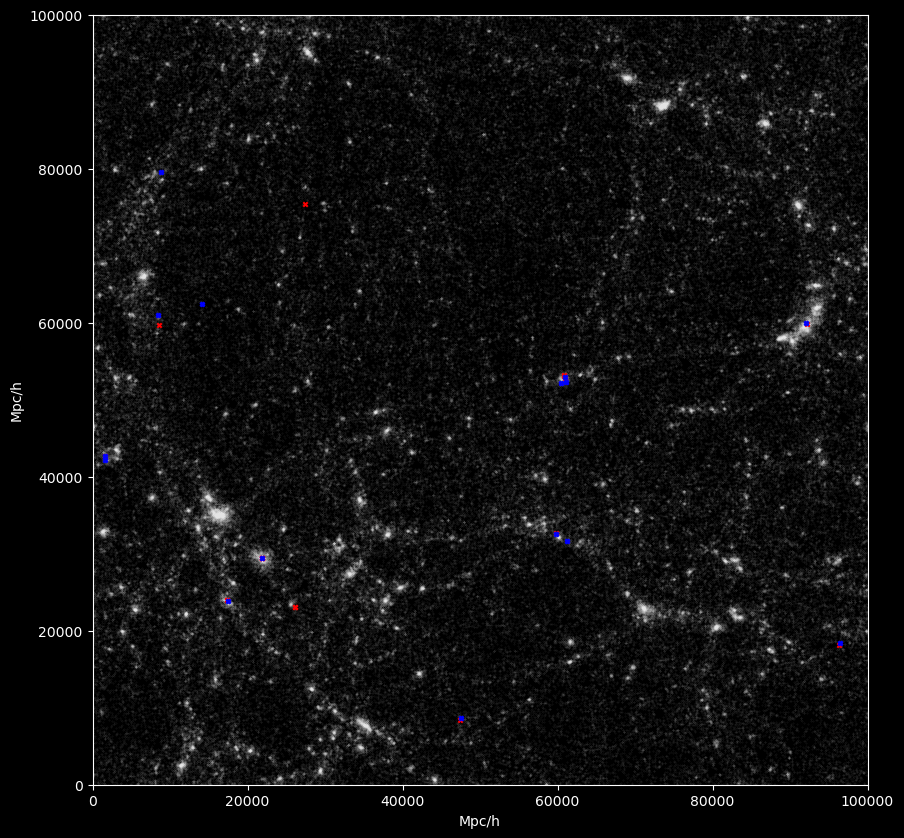

In [30]:
plt.figure(figsize=(10,10))
sct = plt.scatter(du,dv,s=0.1,alpha=0.1,c='white')
sct = plt.scatter(su,sv,marker='x',s=10,alpha=1,c='r')
sct = plt.scatter(bu,bv,marker='X',s=10,alpha=1,c='b')
# plt.colorbar(sct)
plt.xlabel('Mpc/h')
plt.ylabel('Mpc/h')
plt.xlim(0,100000)
plt.ylim(0,100000)

In [6]:
pig = sim.PIG(31)
munit = 1e10
mass = pig.FOFGroups.MassByType().T[0]*munit
box_size = pig.Header.BoxSize()/1000

In [ ]:
BINS = np.logspace(8,13,41)
def get_hmf(filename, box_size):
    # filepath = '{}'
    pass

In [ ]:
from sph_vis import render_projection

# Load or generate particle data
n_particles = 100_000
positions = np.random.uniform(0, 1, size=(n_particles, 3)).astype(np.float32)
masses = np.ones(n_particles, dtype=np.float32) * 1e-3  # particle masses
hs = np.ones(n_particles, dtype=np.float32) * 0.05      # smoothing lengths

# Render density projection (mass-weighted)
density_image, weights = render_projection(
    positions=positions, 
    masses=masses, 
    hs=hs, 
    field=None,              # None = density visualization
    plane="xy",              # Project onto xy plane
    box=(1.0, 1.0, 1.0),     # Periodic box size (optional)
    image_shape=(1024, 1024), # Output resolution
    kernel="cubic",          # SPH kernel type
    method="numba"           # Computation method
)

# Visualize the result
plt.figure(figsize=(10, 8))
plt.imshow(np.log10(density_image + 1e-10), origin='lower', 
           extent=[0, 1, 0, 1], cmap='viridis')
plt.colorbar(label='log₁₀(Density)')
plt.xlabel('X [code units]')
plt.ylabel('Y [code units]')
plt.title('SPH Density Projection')
plt.show()

- 4mpc 64 cube
- halo mass / omegab/omega_m
- (Mb/Mh)/(omega_b/omega_m)